In [10]:
# Imports
import os
from pathlib import Path
markers = (".git", "Program")
current_dir = Path.cwd()
project_root = next((path for path in (current_dir, *current_dir.parents) if any((path / marker).exists() for marker in markers)), current_dir)
os.chdir(project_root)

from backtest import *
import concurrent.futures
import datetime as dt
from functools import partial
from fundamentals import *
from helper_functions import modify_current_date, get_df, get_excel_filename, get_infix, get_volume5m_data, generate_end_dates, merge_stocks, stock_market
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import multiprocessing
import numpy as np
import pandas as pd
from pandas import ExcelWriter as EW
from plot import *
import random
from scipy.optimize import minimize
from scipy.stats import false_discovery_control, kendalltau, linregress, pearsonr, spearmanr, ttest_ind, wilcoxon
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from stock_screener import check_conds_tech, check_conds_fund, EM_rating, get_stock_info, stoploss_target
from technicals import *
from tqdm import tqdm

# Connect to TradingView
from tvDatafeed import TvDatafeed, Interval
tv = TvDatafeed()

# Start of the program
start = dt.datetime.now()

# Index
index_name = "^GSPC"
index_dict = {"^HSI": "HKEX", "^GSPC": "S&P 500", "^IXIC": "NASDAQ Composite"}

# Modify the current date
current_date = modify_current_date(start, index_name)

you are using nologin method, data you access may be limited


In [11]:
def get_parameters():
    """Return default parameters for stock analysis.
    
    Returns:
    dict: Configuration parameters including:
    - days_per_week: Trading days per week
    - period_week_zscore: Lookback period for weekly z-score calculation
    - period_pca: Period for correlation/clustering analysis
    - period_mom_short/long: Short and long-term momentum periods
    - period_vol: Volatility calculation period
    - num_clusters: Number of clusters for hierarchical clustering
    """
    days_per_week = 5
    num_weeks = 52
    return {
        "days_per_week": days_per_week,
        "period_week_zscore": days_per_week * num_weeks,
        "period_pca": 126,
        "period_mom_short": 21,
        "period_mom_long": 252,
        "period_vol": 60,
        "num_clusters": 5,
    }

def fetch_price_data(stocks, current_date):
    """Fetch historical price data for all stocks.
    
    Args:
    - stocks: List of stock tickers
    - current_date: End date for data retrieval
        
    Returns:
        dict: Mapping of stock ticker to closing price series
    """
    price_data = {}
    for stock in tqdm(stocks, desc="Fetching price data"):
        df = get_df(stock, current_date)
        price_data[stock] = df["Close"]
    return price_data

def calculate_weekly_zscore(price_data, stocks, params):
    """Calculate weekly return z-scores to identify statistical outliers.
    
    Z-score measures how many standard deviations the recent weekly return
    is from the historical mean. High z-scores indicate unusually strong returns.
    
    Args:
    - price_data: Dict of stock ticker to price series
    - stocks: List of stock tickers
    - params: Parameters dict containing period settings
        
    Returns:
        tuple: (mean_return, std_return, recent_return, z_scores) as Series
    """
    df_prices_weekly = pd.DataFrame({
        stock: price_data[stock].tail(params["period_week_zscore"] + params["days_per_week"]) 
        for stock in stocks
    })
    weekly_prices = df_prices_weekly.iloc[::params["days_per_week"]]
    weekly_returns = weekly_prices.pct_change(fill_method=None).dropna()
    
    mean_return = weekly_returns.mean()
    std_return = weekly_returns.std()
    recent_return = weekly_returns.iloc[-1]
    z_scores = (recent_return - mean_return) / std_return
    
    return mean_return, std_return, recent_return, z_scores

def calculate_momentum_volatility(price_data, stocks, params):
    """Calculate momentum and volatility metrics for all stocks.
    
    Momentum: Ratio of short-term to long-term price (higher = stronger trend)
    Volatility: Standard deviation of daily returns over the vol period
    
    Args:
    - price_data: Dict of stock ticker to price series
    - stocks: List of stock tickers
    - params: Parameters dict containing period settings
        
    Returns:
    - tuple: (momentum_list, volatility_list) as lists aligned with stocks
    """
    momentum_list = []
    volatility_list = []
    
    for stock in tqdm(stocks, desc="Calculating momentum and volatility"):
        close = price_data[stock]
        momentum = close.iloc[-params["period_mom_short"]] / close.iloc[-params["period_mom_long"]] if len(close) >= params["period_mom_long"] else np.nan
        volatility = close.pct_change().tail(params["period_vol"]).std()
        momentum_list.append(momentum)
        volatility_list.append(volatility)
    
    return momentum_list, volatility_list

def perform_clustering(price_data, stocks, params):
    """Perform hierarchical clustering on stocks based on return correlations.
    
    Uses Ward's method on a distance matrix derived from correlation matrix.
    Stocks with similar return patterns are grouped into the same cluster.
    
    Args:
    - price_data: Dict of stock ticker to price series
    - stocks: List of stock tickers
    - params: Parameters dict containing period and cluster settings
        
    Returns:
        tuple: (Z linkage matrix, cluster_labels array)
    """
    df_prices_cluster = pd.DataFrame({stock: price_data[stock].tail(params["period_pca"]) for stock in stocks})
    returns = df_prices_cluster.pct_change(fill_method=None).dropna()
    corr_matrix = returns.corr()
    corr_matrix = corr_matrix.fillna(0)
    
    # Convert correlation to distance: uncorrelated = sqrt(2), perfectly correlated = 0
    dist_matrix = np.sqrt(2 * (1 - corr_matrix))
    dist_matrix = np.nan_to_num(dist_matrix, nan=0.0, posinf=2.0, neginf=0.0)
    condensed_dist = squareform(dist_matrix, checks=False)
    Z = linkage(condensed_dist, method="ward")
    cluster_labels = fcluster(Z, t=params["num_clusters"], criterion="maxclust")
    return Z, cluster_labels

def build_combined_dataframe(stocks, cluster_labels, momentum_list, volatility_list, mean_return, std_return, recent_return, z_scores):
    """Combine all computed metrics into a single ranked DataFrame.
    
    Calculates volatility-adjusted momentum (Momentum / Volatility) to identify
    stocks with strong trends relative to their risk level.
    
    Args:
    - stocks: List of stock tickers
    - cluster_labels: Cluster assignment for each stock
    - momentum_list: Momentum values for each stock
    - volatility_list: Volatility values for each stock
    - mean_return: Mean weekly return series
    - std_return: Std of weekly return series
    - recent_return: Most recent weekly return series
    - z_scores: Z-score series
        
    Returns:
    - DataFrame: Ranked by Vol-adj Momentum with 1-based index
    """
    df_combined = pd.DataFrame({
        "Stock": stocks,
        "Cluster": cluster_labels,
        "Momentum": momentum_list,
        "Volatility": volatility_list,
        "Mean Weekly Return (%)": (mean_return * 100).values,
        "Std Weekly Return (%)": (std_return * 100).values,
        "This Week Return (%)": (recent_return * 100).values,
        "Z-Score": z_scores.values
    })
    df_combined["Vol-adj Momentum"] = df_combined["Momentum"] / df_combined["Volatility"]
    df_combined = df_combined.sort_values("Vol-adj Momentum", ascending=False).reset_index(drop=True)
    df_combined = df_combined.set_index(df_combined.index + 1)
    df_combined.index.name = "Rank"
    return df_combined

def display_results(df_combined, Z, stocks, params, zscore_threshold=2):
    """Display analysis results including table, dendrogram, and cluster summary.
    
    Filters stocks by z-score threshold to exclude recent outliers,
    then groups remaining stocks by cluster for diversified selection.
    
    Args:
    - df_combined: Combined metrics DataFrame
    - Z: Linkage matrix for dendrogram
    - stocks: List of stock tickers
    - params: Parameters dict
    - zscore_threshold: Max z-score for filtered display (default 2)
    """
    pd.set_option("display.max_rows", None)
    display(df_combined)
    
    plt.figure(figsize=(14, 8))
    dendrogram(Z, labels=stocks, leaf_rotation=90, leaf_font_size=8)
    plt.title(f"Hierarchical Clustering of {len(stocks)} Stocks (Past {params['period_pca']} Days)")
    plt.ylabel("Distance")
    plt.tight_layout()
    plt.show()
    
    df_filtered = df_combined[df_combined["Z-Score"] <= zscore_threshold]
    print(f"\nStocks by Cluster (Ranked by Vol-adj Momentum, Z-Score <= {zscore_threshold}):\n")
    for cluster_id in sorted(df_filtered["Cluster"].unique()):
        cluster_df = df_filtered[df_filtered["Cluster"] == cluster_id].sort_values("Vol-adj Momentum", ascending=False)
        cluster_stocks = cluster_df["Stock"].tolist()
        print(f"Cluster {cluster_id} ({len(cluster_df)} stocks): {', '.join(cluster_stocks)}")

def run_stock_analysis(stocks, current_date, display=True):
    """Run the complete stock analysis pipeline.
    
    Pipeline steps:
    1. Fetch price data for all stocks
    2. Calculate weekly return z-scores
    3. Calculate momentum and volatility
    4. Perform hierarchical clustering
    5. Build combined metrics DataFrame
    6. Optionally display results
    
    Args:
    - stocks: List of stock tickers to analyze
    - current_date: Analysis date (end date for data)
    - display: Whether to show results (default True)
        
    Returns:
    - DataFrame: Combined metrics ranked by Vol-adj Momentum
    """
    params = get_parameters()
    price_data = fetch_price_data(stocks, current_date)
    mean_return, std_return, recent_return, z_scores = calculate_weekly_zscore(price_data, stocks, params)
    momentum_list, volatility_list = calculate_momentum_volatility(price_data, stocks, params)
    Z, cluster_labels = perform_clustering(price_data, stocks, params)
    df_combined = build_combined_dataframe(stocks, cluster_labels, momentum_list, volatility_list, mean_return, std_return, recent_return, z_scores)
    if display:
        display_results(df_combined, Z, stocks, params)
    return df_combined

In [12]:
# Rebalance dates for monthly portfolio analysis
rebalance_dates = [
    "2025-01-04", "2025-02-01", "2025-03-01", "2025-04-05", "2025-05-01", "2025-06-03",
    "2025-07-01", "2025-08-01", "2025-09-06", "2025-10-01", "2025-11-01", "2025-12-04", "2026-01-03"
]

# Parameters
min_market_cap = 10  # Minimum market cap in billions USD
lookback_period = 252
volume_period = 90

def get_filtered_stocks(date, index_name, index_dict, lookback_period, volume_period, min_market_cap):
    """Load excel file and filter stocks by market cap threshold."""
    excel_filename = get_excel_filename(date, index_name, index_dict, lookback_period, volume_period, True)
    excel_df = pd.read_excel(excel_filename)
    stocks = excel_df.loc[excel_df["Market Cap (B, USD)"] > min_market_cap, "Stock"].tolist()
    print(f"{date}: {len(stocks)} stocks from {excel_filename}")
    return stocks

def build_portfolio(df_combined):
    """Build risk-parity portfolio from top stock in each cluster."""
    top_per_cluster = df_combined.groupby("Cluster").first().reset_index()
    inv_vol = 1 / top_per_cluster["Volatility"]
    weights = inv_vol / inv_vol.sum() * 100
    
    return pd.DataFrame({
        "Cluster": top_per_cluster["Cluster"],
        "Stock": top_per_cluster["Stock"],
        "Volatility": top_per_cluster["Volatility"],
        "Weight (%)": weights.values
    })

# Extract stocks and build portfolios for each rebalance date
monthly_stocks = {
    date: get_filtered_stocks(date, index_name, index_dict, lookback_period, volume_period, min_market_cap)
    for date in rebalance_dates
}

monthly_portfolios = {}
for date in rebalance_dates:
    print(f"\nRebalance Date: {date}")
    df_combined = run_stock_analysis(monthly_stocks[date], date, display=False)
    monthly_portfolios[date] = build_portfolio(df_combined)
    display(monthly_portfolios[date])


2025-01-04: 35 stocks from Result/01-04-25/NASDAQstock_01-04-25period252RS90.xlsx
2025-02-01: 67 stocks from Result/02-01-25/NASDAQstock_02-01-25period252RS90.xlsx
2025-03-01: 43 stocks from Result/03-01-25/NASDAQstock_03-01-25period252RS90.xlsx
2025-04-05: 7 stocks from Result/04-05-25/NASDAQstock_04-05-25period252RS90.xlsx
2025-05-01: 34 stocks from Result/05-01-25/NASDAQstock_05-01-25period252RS90.xlsx
2025-06-03: 53 stocks from Result/06-03-25/NASDAQstock_06-03-25period252RS90.xlsx
2025-07-01: 50 stocks from Result/07-01-25/NASDAQstock_07-01-25period252RS90.xlsx
2025-08-01: 57 stocks from Result/08-01-25/NASDAQstock_08-01-25period252RS90.xlsx
2025-09-06: 53 stocks from Result/09-06-25/NASDAQstock_09-06-25period252RS90.xlsx
2025-10-01: 45 stocks from Result/10-01-25/NASDAQstock_10-01-25period252RS90.xlsx
2025-11-01: 52 stocks from Result/11-01-25/NASDAQstock_11-01-25period252RS90.xlsx
2025-12-04: 64 stocks from Result/12-04-25/NASDAQstock_12-04-25period252RS90.xlsx
2026-01-03: 75 st

Calculating momentum and volatility: 100%|██████████| 35/35 [00:00<00:00, 3301.26it/s]


,Cluster,Stock,Volatility,Weight (%)
0,1,HWM,0.016756,20.384079
1,2,PLTR,0.031954,10.689425
2,3,BCS,0.015380,22.208595
3,4,WMT,0.014319,23.853815
4,5,FOX,0.014939,22.864085



Rebalance Date: 2025-02-01


Calculating momentum and volatility: 100%|██████████| 67/67 [00:00<00:00, 3673.44it/s]


...

Calculating momentum and volatility: 100%|██████████| 64/64 [00:00<00:00, 3611.11it/s]


,Cluster,Stock,Volatility,Weight (%)
0,1,AU,0.036414,9.844882
1,2,APH,0.022580,15.876383
2,3,SAN,0.014879,24.092922
3,4,BSAC,0.012841,27.918244
4,5,MT,0.016099,22.267569



Rebalance Date: 2026-01-03


Calculating momentum and volatility: 100%|██████████| 75/75 [00:00<00:00, 3745.18it/s]


,Cluster,Stock,Volatility,Weight (%)
0,1,B,0.029154,12.212584
1,2,SAN,0.014879,23.929062
2,3,APH,0.022580,15.768405
3,4,LTM,0.017486,20.361582
4,5,BSAC,0.012841,27.728368


In [13]:
mmth_df = get_df("MMTH", current_date, method="tradingview")
mmfi_df = get_df("MMFI", current_date, method="tradingview")

,Total Return (%),Annualized Return (%),Annualized Volatility (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Calmar Ratio
Portfolio (Layers),40.137031,41.899478,17.677031,1.907650,2.599885,-8.173818,5.126059
Portfolio (Layers + Wait),42.049618,43.908352,17.796851,1.975424,2.719665,-8.173818,5.371829
Portfolio (No Filter),73.846885,77.444272,29.456979,2.001150,2.685572,-16.096664,4.811200
S&P 500,14.778815,14.969585,18.781437,0.679024,0.858025,-18.902206,0.791949


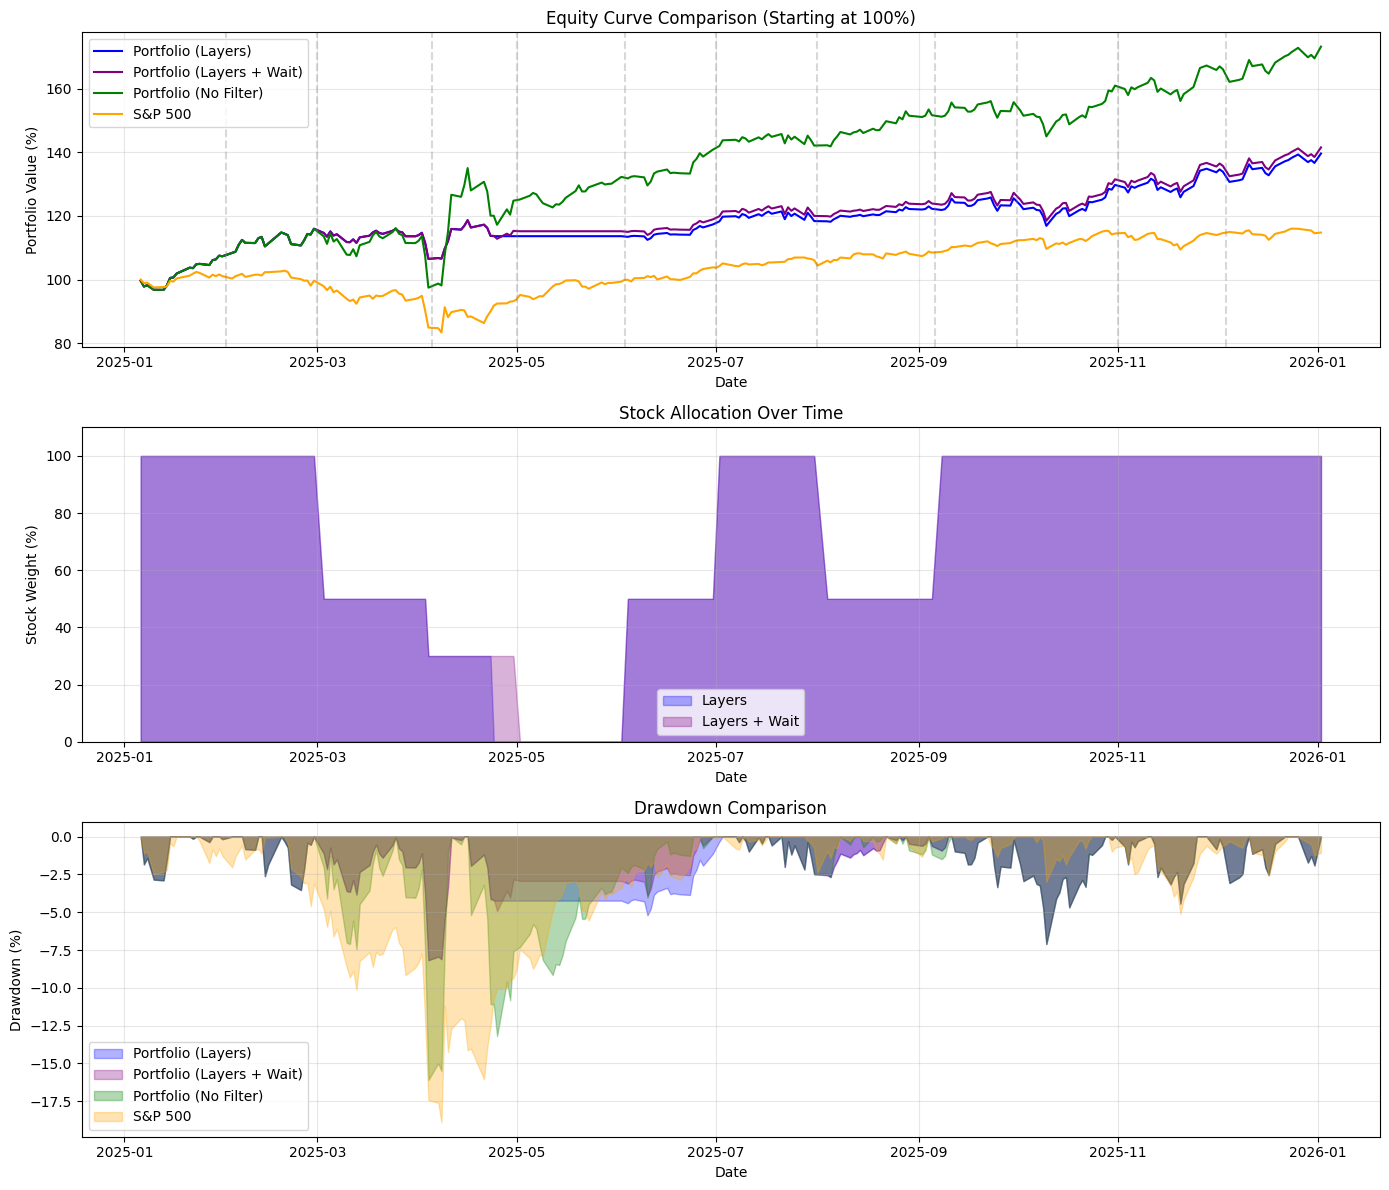


Portfolio Comparison Summary (with 0.1% trading fee):
Metric                                Layers      Wait Recovery          No Filter         S&P 500
Total Return (%)                       40.14              42.05              73.85           14.78
Annualized Return (%)                  41.90              43.91              77.44           14.97
Annualized Volatility (%)              17.68              17.80              29.46           18.78
Sharpe Ratio                            1.91               1.98               2.00            0.68
Sortino Ratio                           2.60               2.72               2.69            0.86
Max Drawdown (%)                       -8.17              -8.17             -16.10          -18.90
Calmar Ratio                            5.13               5.37               4.81            0.79


In [17]:
# Backtest monthly portfolios with daily equity curve using S&P 500 SMA 200 filter and MMFI/MMTH layers

# CONSTANTS
TRADING_FEE = 0.001  # 0.1% fee per trade (buy or sell)
RISK_FREE_RATE = 0.03
DAILY_RF = RISK_FREE_RATE / 252
INITIAL_VALUE = 100.0

# DATA PREPARATION
sp500_df = get_df("^GSPC", current_date)
sp500_df["SMA 200"] = SMA(sp500_df, 200)

# HELPER FUNCTIONS
def get_price_on_date(stock_df, target_date, price_type="Close"):
    """Get price for a stock on a specific date with fallback to nearest available."""
    if target_date in stock_df.index:
        return stock_df.loc[target_date, price_type]
    
    idx = stock_df.index.searchsorted(target_date)
    if price_type == "Open" and idx < len(stock_df):
        return stock_df.iloc[idx][price_type]
    elif idx > 0:
        return stock_df.iloc[idx - 1]["Close"]
    return None

def get_indicator_on_date(indicator_df, target_date):
    """Get indicator value (MMFI/MMTH) on a specific date with fallback."""
    if target_date in indicator_df.index:
        return indicator_df.loc[target_date, "Close"]
    idx = indicator_df.index.searchsorted(target_date)
    return indicator_df.iloc[idx - 1]["Close"] if idx > 0 else None

def apply_fee(value, fee_rate=TRADING_FEE):
    """Apply trading fee to a value."""
    return value * (1 - fee_rate)

# LAYER LOGIC
def calculate_layer_a_weight(sp500_close, sp500_sma200, mmth_value):
    """
    Calculate stock weighting based on Layer A rules (rebalance dates only).
    
    Rules:
    - S&P 500 above SMA200 AND MMTH > 50: 100% stocks
    - S&P 500 above SMA200 OR MMTH > 50: 50% stocks
    - Neither condition met: 0% stocks (all cash)
    """
    sp500_above_sma = sp500_close > sp500_sma200 if pd.notna(sp500_sma200) else True
    mmth_above_50 = mmth_value > 50 if pd.notna(mmth_value) else True
    
    if sp500_above_sma and mmth_above_50:
        return 1.0
    elif sp500_above_sma or mmth_above_50:
        return 0.5
    return 0.0

# PORTFOLIO CALCULATIONS
def calculate_portfolio_value(portfolio, buy_prices, trade_date, base_value, 
                              stock_data_cache, stock_weight=1.0):
    """Calculate portfolio value based on current prices and stock weighting."""
    if stock_weight == 0 or not buy_prices:
        return base_value
    
    total_return = 0.0
    for _, row in portfolio.iterrows():
        stock, weight = row["Stock"], row["Weight (%)"] / 100
        if stock not in buy_prices:
            continue
        
        close_price = get_price_on_date(stock_data_cache[stock], trade_date, "Close")
        if close_price:
            stock_return = (close_price - buy_prices[stock]) / buy_prices[stock]
            total_return += weight * stock_return
    
    stock_portion = base_value * stock_weight * (1 + total_return)
    cash_portion = base_value * (1 - stock_weight)
    return stock_portion + cash_portion

def calculate_metrics(daily_returns, equity_curve):
    """Calculate key performance metrics for a strategy."""
    total_return = (equity_curve.iloc[-1] / equity_curve.iloc[0]) - 1
    n_days = len(equity_curve)
    annualized_return = (1 + total_return) ** (252 / n_days) - 1
    annualized_vol = daily_returns.std() * np.sqrt(252)
    
    excess_returns = daily_returns - DAILY_RF
    sharpe = (excess_returns.mean() * 252) / annualized_vol if annualized_vol > 0 else np.nan
    
    downside_returns = daily_returns[daily_returns < DAILY_RF]
    downside_std = downside_returns.std() * np.sqrt(252)
    sortino = (excess_returns.mean() * 252) / downside_std if downside_std > 0 else np.nan
    
    rolling_max = equity_curve.cummax()
    drawdown = (equity_curve - rolling_max) / rolling_max
    max_drawdown = drawdown.min()
    calmar = annualized_return / abs(max_drawdown) if max_drawdown != 0 else np.nan
    
    return {
        "Total Return (%)": total_return * 100,
        "Annualized Return (%)": annualized_return * 100,
        "Annualized Volatility (%)": annualized_vol * 100,
        "Sharpe Ratio": sharpe,
        "Sortino Ratio": sortino,
        "Max Drawdown (%)": max_drawdown * 100,
        "Calmar Ratio": calmar
    }

# BACKTEST ENGINE
def run_backtest(use_layers=True, wait_for_rebalance=False):
    """
    Run backtest with optional Layer A (market regime) and Layer B (panic mode) logic.
    
    Layer A: Adjusts stock allocation based on S&P 500 vs SMA200 and MMTH at rebalance.
    Layer B: Reduces to 30% stocks when MMFI < 10 (panic), recovers when MMFI > 30.
    
    Parameters:
    - use_layers: If True, applies Layer A and B logic. If False, remains fully invested.
    - wait_for_rebalance: If True, when MMFI > 30 triggers recovery from panic mode,
      it does not sell/rebalance immediately but waits for the next scheduled rebalance date.
      The panic allocation (30%) is held until then.
    """
    daily_equity = []
    current_value = INITIAL_VALUE
    stock_data_cache = {}
    panic_mode = False
    
    # Track if we are in "waiting for rebalance" state after panic recovery signal
    waiting_recovery = False 

    for i in range(len(rebalance_dates) - 1):
        start_date, end_date = rebalance_dates[i], rebalance_dates[i + 1]
        
        if start_date not in monthly_portfolios:
            continue
        
        portfolio = monthly_portfolios[start_date]
        start_dt, end_dt = pd.to_datetime(start_date), pd.to_datetime(end_date)
        
        # Determine trading period
        valid_buy_dates = sp500_df.index[sp500_df.index > start_dt]
        valid_sell_dates = sp500_df.index[sp500_df.index < end_dt]
        if len(valid_buy_dates) == 0 or len(valid_sell_dates) == 0:
            continue
        
        buy_date = valid_buy_dates[0]
        sell_date = valid_sell_dates[-1]
        period_dates = sp500_df.index[(sp500_df.index >= buy_date) & (sp500_df.index <= sell_date)]
        
        # Get market conditions at rebalance for Layer A
        rebalance_check_dates = sp500_df.index[sp500_df.index <= start_dt]
        if len(rebalance_check_dates) == 0:
            continue
        
        rebalance_check_date = rebalance_check_dates[-1]
        sp500_close = sp500_df.loc[rebalance_check_date, "Close"]
        sp500_sma200 = sp500_df.loc[rebalance_check_date, "SMA 200"]
        mmth_value = get_indicator_on_date(mmth_df, rebalance_check_date)
        
        # At start of new period:
        # If we were waiting for recovery, the wait is over, reset panic flags.
        if waiting_recovery:
            panic_mode = False
            waiting_recovery = False
        
        # Calculate initial stock weight        
        layer_a_weight = calculate_layer_a_weight(sp500_close, sp500_sma200, mmth_value) if use_layers else 1.0
        
        # Determine starting weight for this month
        if panic_mode:
            current_stock_weight = 0.3
        else:
            current_stock_weight = layer_a_weight
        
        # Cache stock data and get buy prices
        buy_prices = {}
        if current_stock_weight > 0:
            for _, row in portfolio.iterrows():
                stock = row["Stock"]
                if stock not in stock_data_cache:
                    stock_data_cache[stock] = get_df(stock, current_date)
                price = get_price_on_date(stock_data_cache[stock], buy_date, "Open")
                if price:
                    buy_prices[stock] = price
            current_value = apply_fee(current_value)
        
        period_start_value = current_value
        
        # Daily tracking through the period
        for trade_date in period_dates:
            # Layer B: Check MMFI for panic mode transitions
            if use_layers:
                mmfi_value = get_indicator_on_date(mmfi_df, trade_date)
                
                if mmfi_value is not None:
                    # Enter panic mode
                    if not panic_mode and mmfi_value < 10:
                        panic_mode = True
                        waiting_recovery = False # Reset any waiting status
                        
                        current_portfolio_value = calculate_portfolio_value(
                            portfolio, buy_prices, trade_date, period_start_value,
                            stock_data_cache, current_stock_weight
                        )
                        current_value = apply_fee(current_portfolio_value)
                        period_start_value = current_value
                        current_stock_weight = 0.3
                        
                        # Update buy prices to current to lock in the drop/change
                        for _, row in portfolio.iterrows():
                            stock = row["Stock"]
                            if stock in stock_data_cache:
                                price = get_price_on_date(stock_data_cache[stock], trade_date, "Close")
                                if price:
                                    buy_prices[stock] = price
                    
                    # Logically exit panic mode (MMFI > 30)
                    elif panic_mode and mmfi_value > 30 and not waiting_recovery:
                        
                        if wait_for_rebalance:
                            # Do NOT trade now. Just mark that we have seen the signal.
                            # We stay in panic_mode (weight 0.3) until end of month loop.
                            waiting_recovery = True
                            # No fee, no weight change, no price update needed.
                            
                        else:
                            # Immediate recovery logic
                            panic_mode = False
                            current_portfolio_value = calculate_portfolio_value(
                                portfolio, buy_prices, trade_date, period_start_value,
                                stock_data_cache, 0.3
                            )
                            current_value = apply_fee(current_portfolio_value)
                            period_start_value = current_value
                            
                            # Recalculate Layer A weight with current conditions
                            sp500_close_now = sp500_df.loc[trade_date, "Close"] if trade_date in sp500_df.index else sp500_close
                            sp500_sma200_now = sp500_df.loc[trade_date, "SMA 200"] if trade_date in sp500_df.index else sp500_sma200
                            mmth_now = get_indicator_on_date(mmth_df, trade_date)
                            current_stock_weight = calculate_layer_a_weight(sp500_close_now, sp500_sma200_now, mmth_now)
                            
                            # Update buy prices
                            for _, row in portfolio.iterrows():
                                stock = row["Stock"]
                                if stock in stock_data_cache:
                                    price = get_price_on_date(stock_data_cache[stock], trade_date, "Close")
                                    if price:
                                        buy_prices[stock] = price
            
            # Record daily portfolio value
            portfolio_value = calculate_portfolio_value(
                portfolio, buy_prices, trade_date, period_start_value,
                stock_data_cache, current_stock_weight
            )
            
            daily_equity.append({
                "Date": trade_date,
                "Portfolio Value": portfolio_value,
                "Period": i + 1,
                "Stock Weight": current_stock_weight,
                "Panic Mode": panic_mode,
                "Wait Recovery": waiting_recovery
            })
        
        # End of period: apply sell fee if holding stocks
        if current_stock_weight > 0 and daily_equity:
            current_value = apply_fee(daily_equity[-1]["Portfolio Value"])
        elif daily_equity:
            current_value = daily_equity[-1]["Portfolio Value"]
            
    return pd.DataFrame(daily_equity).set_index("Date")

# RUN BACKTESTS
daily_equity_df = run_backtest(use_layers=True, wait_for_rebalance=False)
daily_equity_wait_df = run_backtest(use_layers=True, wait_for_rebalance=True)
daily_equity_no_filter_df = run_backtest(use_layers=False)

# BENCHMARK & METRICS
sp500_period = sp500_df.loc[daily_equity_df.index.min():daily_equity_df.index.max(), "Close"]
sp500_equity = 100 * sp500_period / sp500_period.iloc[0]

portfolio_daily_returns = daily_equity_df["Portfolio Value"].pct_change().dropna()
portfolio_wait_daily_returns = daily_equity_wait_df["Portfolio Value"].pct_change().dropna()
portfolio_no_filter_daily_returns = daily_equity_no_filter_df["Portfolio Value"].pct_change().dropna()
sp500_daily_returns = sp500_equity.pct_change().dropna()

portfolio_metrics = calculate_metrics(portfolio_daily_returns, daily_equity_df["Portfolio Value"])
portfolio_wait_metrics = calculate_metrics(portfolio_wait_daily_returns, daily_equity_wait_df["Portfolio Value"])
portfolio_no_filter_metrics = calculate_metrics(portfolio_no_filter_daily_returns, daily_equity_no_filter_df["Portfolio Value"])
sp500_metrics = calculate_metrics(sp500_daily_returns, sp500_equity)

metrics_df = pd.DataFrame({
    "Portfolio (Layers)": portfolio_metrics,
    "Portfolio (Layers + Wait)": portfolio_wait_metrics,
    "Portfolio (No Filter)": portfolio_no_filter_metrics,
    "S&P 500": sp500_metrics
}).T
display(metrics_df)

# VISUALIZATION
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Equity curves
axes[0].plot(daily_equity_df.index, daily_equity_df["Portfolio Value"], 
             linewidth=1.5, color="blue", label="Portfolio (Layers)")
axes[0].plot(daily_equity_wait_df.index, daily_equity_wait_df["Portfolio Value"], 
             linewidth=1.5, color="purple", label="Portfolio (Layers + Wait)")
axes[0].plot(daily_equity_no_filter_df.index, daily_equity_no_filter_df["Portfolio Value"], 
             linewidth=1.5, color="green", label="Portfolio (No Filter)")
axes[0].plot(sp500_equity.index, sp500_equity.values, 
             linewidth=1.5, color="orange", label="S&P 500")

for date in rebalance_dates[1:-1]:
    dt = pd.to_datetime(date)
    if daily_equity_df.index.min() <= dt <= daily_equity_df.index.max():
        axes[0].axvline(x=dt, color="gray", linestyle="--", alpha=0.3)

axes[0].set_xlabel("Date")
axes[0].set_ylabel("Portfolio Value (%)")
axes[0].set_title("Equity Curve Comparison (Starting at 100%)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Stock allocation
axes[1].fill_between(daily_equity_df.index, daily_equity_df["Stock Weight"] * 100, 
                     alpha=0.3, color="blue", label="Layers")
axes[1].fill_between(daily_equity_wait_df.index, daily_equity_wait_df["Stock Weight"] * 100, 
                     alpha=0.3, color="purple", label="Layers + Wait")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Stock Weight (%)")
axes[1].set_title("Stock Allocation Over Time")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 110)

# Drawdowns
portfolio_drawdown = (daily_equity_df["Portfolio Value"] - daily_equity_df["Portfolio Value"].cummax()) / daily_equity_df["Portfolio Value"].cummax() * 100
portfolio_wait_drawdown = (daily_equity_wait_df["Portfolio Value"] - daily_equity_wait_df["Portfolio Value"].cummax()) / daily_equity_wait_df["Portfolio Value"].cummax() * 100
portfolio_no_filter_drawdown = (daily_equity_no_filter_df["Portfolio Value"] - daily_equity_no_filter_df["Portfolio Value"].cummax()) / daily_equity_no_filter_df["Portfolio Value"].cummax() * 100
sp500_drawdown = (sp500_equity - sp500_equity.cummax()) / sp500_equity.cummax() * 100

axes[2].fill_between(portfolio_drawdown.index, portfolio_drawdown.values, 
             alpha=0.3, linewidth=1, color="blue", label="Portfolio (Layers)")
axes[2].fill_between(portfolio_wait_drawdown.index, portfolio_wait_drawdown.values, 
             alpha=0.3, linewidth=1, color="purple", label="Portfolio (Layers + Wait)")
axes[2].fill_between(portfolio_no_filter_drawdown.index, portfolio_no_filter_drawdown.values, 
             alpha=0.3, linewidth=1, color="green", label="Portfolio (No Filter)")
axes[2].fill_between(sp500_drawdown.index, sp500_drawdown.values, 
             alpha=0.3, linewidth=1, color="orange", label="S&P 500")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Drawdown (%)")
axes[2].set_title("Drawdown Comparison")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# SUMMARY
print(f"\nPortfolio Comparison Summary (with {TRADING_FEE*100:.1f}% trading fee):")
print(f"{'Metric':<25} {'Layers':>18} {'Wait Recovery':>18} {'No Filter':>18} {'S&P 500':>15}")
for metric in portfolio_metrics:
    print(f"{metric:<25} {portfolio_metrics[metric]:>18.2f} {portfolio_wait_metrics[metric]:>18.2f} {portfolio_no_filter_metrics[metric]:>18.2f} {sp500_metrics[metric]:>15.2f}")